# Olist：客户生命周期与精细化运营分析

本 Notebook 基于项目汇总结果，串联**客户分层 → Cohort 留存 → 90 天跨日二购 → 履约体验 → 运营建议**。

所有图表与数字均读取项目已生成的真实汇总数据。本 Notebook 不访问原始数据、客户级名单或数据库，不重新执行生产建模与回归流程，也不报告未实施的营销实验结果。

[项目首页](../README.md) · [指标定义](../docs/metric_definitions.md) · [完整分析报告](../docs/project_report.md) · [最终 Tableau 工作簿](../outputs/tableau/Olist_Customer_Lifecycle_Dashboard.twbx)


## 1. 业务问题与数据模型

核心问题：谁值得优先维护？首购之后有多少客户再次购买？履约体验与满意度、二购分别有什么关系？

数据建模先将商品、支付、评价分别聚合至订单粒度，再连接为 `mart_order_summary`（一单一行）；随后按 `customer_unique_id` 汇总为 `mart_customer_features`（一客一行），生成 RFM、生命周期、Cohort 与运营标签。先聚合再 JOIN，用于避免一对多连接造成金额重复计算。

输入为流程导出的群组与指标汇总，无需读取客户级明细。数据模型详见 [ER 图与关系说明](../docs/er_diagram.md)。

### 如何复现

安装仓库的 `requirements.txt` 后，使用 Python 3 内核从头运行全部单元格。克隆仓库中的汇总 CSV 已足够运行，无需 MySQL 或本地完整名单。下面显式列出所有输入，并记录 SHA-256；末尾再次核对输入没有被改写。图中采用英文标签以避免中文字体依赖，正文与表格保留中文。

若希望查看运营交付的记录结构，见 [6 条真实客户样例与字段说明](../docs/customer_samples.md)。该说明页与本 Notebook 的汇总分析分开，样例不是随机样本，也不代表真实触达结果。


In [1]:
from pathlib import Path
from hashlib import sha256

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "sql/10_cohort_retention.sql").is_file()
     and (p / "outputs/tableau/customer_overview.csv").is_file()),
    None,
)
if ROOT is None:
    raise RuntimeError("请在完整项目的根目录或 notebooks 目录中运行。")

SOURCES = {
    "overview": "outputs/tableau/customer_overview.csv",
    "segments": "outputs/tableau/customer_segment_dashboard.csv",
    "cohort": "outputs/tables/cohort_retention_long.csv",
    "repeat_overview": "outputs/tables/repeat_purchase_90d_overview.csv",
    "repeat_drivers": "outputs/tables/repeat_purchase_90d_driver_summary.csv",
    "repeat_groups": "outputs/tables/repeat_purchase_90d_segment_rates.csv",
    "delivery": "outputs/tables/delivery_experience_summary.csv",
    "validation": "outputs/tables/cross_validation_results.csv",
    "campaigns": "outputs/tableau/campaign_dashboard.csv",
}
REQUIRED = {
    "overview": {"customer_count", "order_count", "payment_amount", "repeat_rate", "one_time_rate"},
    "segments": {"segment", "customer_count", "payment_share"},
    "cohort": {"cohort_month", "month_index", "cohort_size", "retained_customers", "retention_pct"},
    "repeat_overview": {"metric", "value"},
    "repeat_drivers": {"model", "driver", "odds_ratio", "ci_95_low", "ci_95_high", "p_value", "n_obs"},
    "repeat_groups": {"dimension", "group", "customer_count", "repeat_customers_90d", "repeat_rate_90d_pct"},
    "delivery": {"metric", "value"},
    "validation": {"metric", "sql_value", "python_value", "status"},
    "campaigns": {"reason_code", "campaign_priority", "customer_count"},
}
data, input_hashes = {}, {}
for key, relative_path in SOURCES.items():
    path = ROOT / relative_path
    if not path.is_file():
        raise FileNotFoundError(f"缺少已发布汇总：{relative_path}")
    input_hashes[key] = sha256(path.read_bytes()).hexdigest()
    frame = pd.read_csv(path)
    assert REQUIRED[key].issubset(frame.columns), f"{key} 的汇总字段不完整"
    assert not any(col.endswith("_id") for col in frame.columns), "展示输入不得包含个体 ID"
    data[key] = frame

plt.rcParams.update({
    "figure.dpi": 110, "font.family": "DejaVu Sans", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlecolor": "#17324D",
})
BLUE, TEAL, ORANGE = "#2F6B9A", "#2A9D8F", "#F4A261"

display(pd.DataFrame([
    {"公开输入": path, "汇总行数": len(data[key]), "SHA-256（前 12 位）": input_hashes[key][:12]}
    for key, path in SOURCES.items()
]))


,公开输入,汇总行数,SHA-256（前 12 位）
0,outputs/tableau/customer_overview.csv,1,54ecb02da2a8
1,outputs/tableau/customer_segment_dashboard.csv,8,29f3c246eeee
2,outputs/tables/cohort_retention_long.csv,255,6f6436393ef0
3,outputs/tables/repeat_purchase_90d_overview.csv,10,4be9ff01f737
4,outputs/tables/repeat_purchase_90d_driver_summ...,12,650a6dd88584
5,outputs/tables/repeat_purchase_90d_segment_rat...,46,128230eaba2e
6,outputs/tables/delivery_experience_summary.csv,21,4678c26dc049
7,outputs/tables/cross_validation_results.csv,11,15979b593749
8,outputs/tableau/campaign_dashboard.csv,6,c292f7648472


## 2. 经营概览：先明确分母

客户价值与分层使用**有已交付订单的客户**；原始客户表的全量真实客户数来自交叉验证表，两者不能混用。历史复购率按观察期内至少两笔已交付订单计算，与后面的 90 天跨日二购率、月度 Cohort 留存是不同口径。


In [2]:
overview = data["overview"].iloc[0]
checks = data["validation"].set_index("metric")
all_customers = int(float(checks.loc["total_customers", "python_value"]))
assert round(float(overview["repeat_rate"] + overview["one_time_rate"]), 2) == 100

display(pd.DataFrame([
    {"指标": "全量真实客户（含无已交付订单者）", "实际值": f"{all_customers:,}"},
    {"指标": "已交付订单客户", "实际值": f"{int(overview['customer_count']):,}"},
    {"指标": "已交付订单", "实际值": f"{int(overview['order_count']):,}"},
    {"指标": "已交付订单支付金额（BRL）", "实际值": f"{overview['payment_amount']:,.2f}"},
    {"指标": "历史一次性购买率", "实际值": f"{overview['one_time_rate']:.2f}%"},
    {"指标": "历史复购率", "实际值": f"{overview['repeat_rate']:.2f}%"},
]))


,指标,实际值
0,全量真实客户（含无已交付订单者）,"96,096"
1,已交付订单客户,"93,358"
2,已交付订单,"96,478"
3,已交付订单支付金额（BRL）,"15,422,461.77"
4,历史一次性购买率,97.00%
5,历史复购率,3.00%


## 3. 客户分层：规模与价值贡献

RFM 衡量最近购买时间、购买频次与消费金额；最终运营分层进一步结合生命周期、购买行为和履约体验，并按优先级互斥归类。

下表中的“高价值已流失客户”是**互斥最终分层**，不等同于“高价值且已流失”的完整交叉人群；履约受损标签优先级更高。


,segment,customer_count,payment_share,average_order_value
0,其他普通客户,31713,23.34,111.93
1,首购未复购客户,28521,17.85,96.52
2,低价值长期沉默客户,10837,2.79,39.70
3,高价值已流失客户,10326,29.12,416.93
4,履约受损客户,4024,4.81,181.24
5,高价值流失风险客户,3761,10.98,428.26
6,高价值活跃客户,3666,10.65,423.91
7,重复购买成长客户,510,0.46,68.01


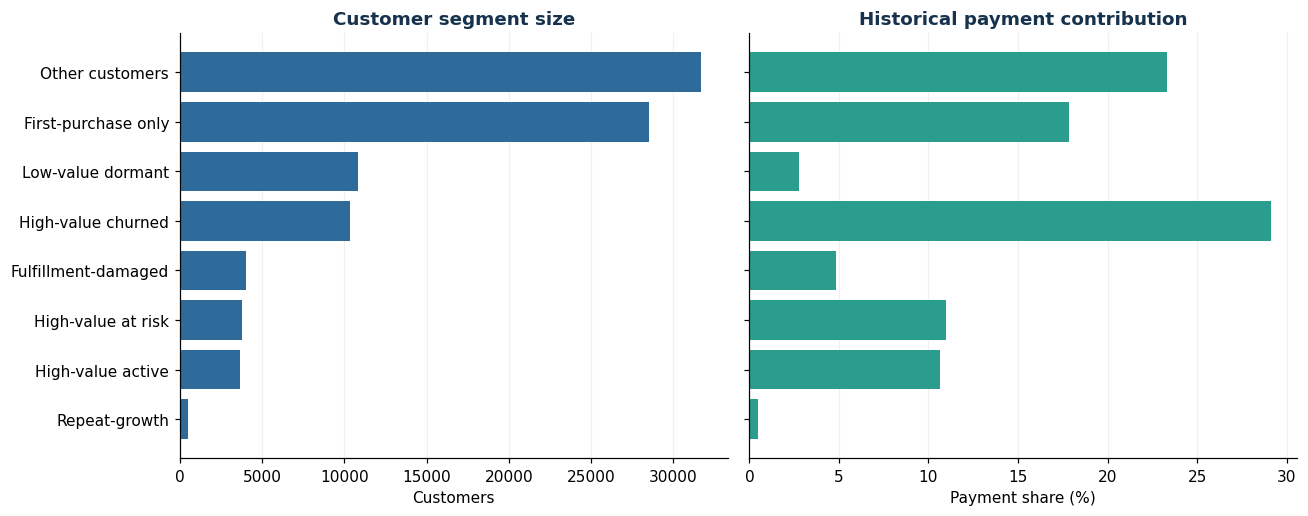

完整高价值流失人群 **10,915** 人；互斥最终分层 **10,326** 人；其中 **589** 人按更高优先级归入履约受损客户。

In [3]:
segments = data["segments"].sort_values("customer_count", ascending=True).copy()
assert int(segments["customer_count"].sum()) == int(overview["customer_count"])
assert abs(segments["payment_share"].sum() - 100) <= 0.05
labels = {
    "其他普通客户": "Other customers",
    "首购未复购客户": "First-purchase only",
    "低价值长期沉默客户": "Low-value dormant",
    "高价值已流失客户": "High-value churned",
    "履约受损客户": "Fulfillment-damaged",
    "高价值流失风险客户": "High-value at risk",
    "高价值活跃客户": "High-value active",
    "重复购买成长客户": "Repeat-growth",
}
display(segments.sort_values("customer_count", ascending=False).reset_index(drop=True))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
axes[0].barh(segments["segment"].map(labels), segments["customer_count"], color=BLUE)
axes[0].set(title="Customer segment size", xlabel="Customers")
axes[1].barh(segments["segment"].map(labels), segments["payment_share"], color=TEAL)
axes[1].set(title="Historical payment contribution", xlabel="Payment share (%)")
for ax in axes:
    ax.grid(axis="x", alpha=0.18)
    ax.set_axisbelow(True)
fig.tight_layout()
plt.show()
plt.close(fig)

full_churned = int(float(checks.loc["high_value_churned", "python_value"]))
final_churned = int(segments.loc[segments["segment"] == "高价值已流失客户", "customer_count"].iloc[0])
display(Markdown(
    f"完整高价值流失人群 **{full_churned:,}** 人；互斥最终分层 **{final_churned:,}** 人；"
    f"其中 **{full_churned - final_churned:,}** 人按更高优先级归入履约受损客户。"
))


## 4. Cohort 留存：加权 M1 KPI 与趋势分开看

Cohort 以首次已交付订单月份分组。汇总长表中行存在即代表该月龄可观察，未来不可观察的单元格不补零，也不改写原始 Cohort 行。

**M1 KPI = ΣM1 留存客户数 / ΣM1 Cohort Size**，使用全部可观察成熟 Cohort。趋势图仅展示 `cohort_size ≥ 100` 的 Cohort；这一筛选不影响上方加权 KPI。M2/M3 的历史简单平均口径不在这里与 M1 混作同一汇总趋势。


### 加权 M1 留存率 0.48%

21 个可观察成熟 Cohort，ΣM1 留存客户数 = **390**，ΣCohort Size = **81,265**。

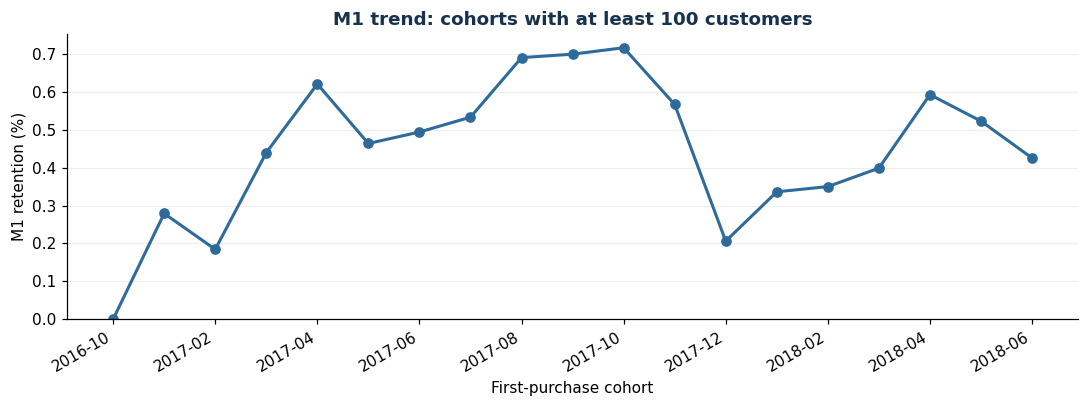

In [4]:
cohort = data["cohort"]
assert not cohort.duplicated(["cohort_month", "month_index"]).any()
m1 = cohort.loc[cohort["month_index"] == 1].copy()
assert not m1.empty and (m1["cohort_size"] > 0).all()
assert m1["retained_customers"].between(0, m1["cohort_size"]).all()
retained = int(m1["retained_customers"].sum())
cohort_size = int(m1["cohort_size"].sum())
weighted_m1_pct = retained / cohort_size * 100
assert round(weighted_m1_pct, 2) == float(checks.loc["m1_retention_pct", "python_value"])

display(Markdown(
    f"### 加权 M1 留存率 {weighted_m1_pct:.2f}%\n\n"
    f"{m1['cohort_month'].nunique()} 个可观察成熟 Cohort，"
    f"ΣM1 留存客户数 = **{retained:,}**，ΣCohort Size = **{cohort_size:,}**。"
))

trend = m1.loc[m1["cohort_size"] >= 100].sort_values("cohort_month").copy()
trend["computed_pct"] = trend["retained_customers"] / trend["cohort_size"] * 100
fig, ax = plt.subplots(figsize=(10, 3.8))
x = np.arange(len(trend))
ax.plot(x, trend["computed_pct"], color=BLUE, marker="o", linewidth=2)
ax.set_xticks(x[::2], trend["cohort_month"].str[:7].iloc[::2], rotation=30, ha="right")
ax.set(title="M1 trend: cohorts with at least 100 customers",
       xlabel="First-purchase cohort", ylabel="M1 retention (%)")
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()
plt.close(fig)


## 5. 首购后 90 天跨日二购：窗口与关联因素

“二购”仅计首购后第 **1–90 个自然日**的下一笔已交付订单，排除同日订单；仅纳入完整 90 天观察窗的首购客户。

下方读取现有概览、分组率和回归汇总，**不重新拟合模型**。完整体验模型控制客户州、主品类和首购月份。赔率比（OR）不是概率提升百分比，也不等于因果效应。不同完整样本的 AIC 不作直接比较。

[90 天二购专题与限制](../docs/repeat_purchase_90d_analysis.md)


In [5]:
repeat = data["repeat_overview"].set_index("metric")["value"]
eligible = int(repeat["eligible_customers"])
repeat_customers = int(repeat["repeat_customers_90d"])
repeat_pct = repeat_customers / eligible * 100
median_days = float(repeat["median_days_to_second_purchase"])
assert round(repeat_pct, 4) == float(repeat["repeat_rate_90d_pct"])

display(pd.DataFrame([
    {"指标": "分析观察日", "实际值": repeat["analysis_date"]},
    {"指标": "成熟首购截止日", "实际值": repeat["mature_first_purchase_cutoff"]},
    {"指标": "成熟首购客户", "实际值": f"{eligible:,}"},
    {"指标": "90 天跨日二购客户", "实际值": f"{repeat_customers:,}"},
    {"指标": "90 天跨日二购率", "实际值": f"{repeat_pct:.4f}%"},
    {"指标": "二购间隔中位数（仅二购者）", "实际值": f"{median_days:g} 天"},
]))
groups = data["repeat_groups"]
for _, group in groups.groupby("dimension"):
    assert int(group["customer_count"].sum()) == eligible
    assert int(group["repeat_customers_90d"].sum()) == repeat_customers
selected_groups = groups.loc[
    groups["dimension"].isin(["item_count_group", "review_group", "delivery_status"]),
    ["dimension", "group", "customer_count", "repeat_customers_90d", "repeat_rate_90d_pct"],
]
display(selected_groups.reset_index(drop=True))


,指标,实际值
0,分析观察日,2018-08-30
1,成熟首购截止日,2018-06-01
2,成熟首购客户,"75,563"
3,90 天跨日二购客户,980
4,90 天跨日二购率,1.2969%
5,二购间隔中位数（仅二购者）,29 天


,dimension,group,customer_count,repeat_customers_90d,repeat_rate_90d_pct
0,delivery_status,delayed,6611,70,1.0588
1,delivery_status,on_time,68950,910,1.3198
2,delivery_status,unknown,2,0,0.0000
3,review_group,high_4_5,58267,795,1.3644
4,review_group,low_1_2,10116,100,0.9885
5,review_group,missing,741,17,2.2942
6,review_group,neutral_3,6439,68,1.0561
7,item_count_group,multi_item,7543,135,1.7897
8,item_count_group,single_item,68020,845,1.2423


,driver_label,odds_ratio,ci_95_low,ci_95_high,p_value,n_obs
driver,,,,,,
multi_item,首单包含多个商品,1.4099,1.1349,1.7515,0.0019,74820
low_score,首单低评分（1–2 分）,0.7371,0.5835,0.9311,0.0105,74820
is_delayed,首单配送延迟,0.9127,0.6890,1.2090,0.5242,74820


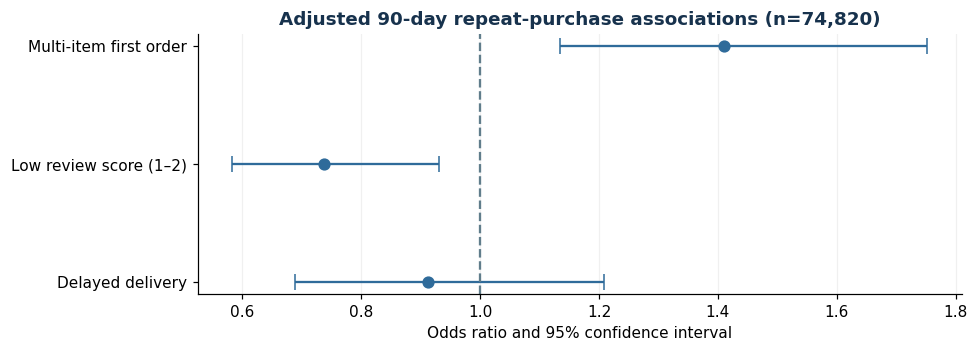

多商品首单 OR **1.4099**，低评分 OR **0.7371**；配送延迟调整后 p=**0.5242**，未发现显著关联。这些是观察性数据中的调整后关联，不是营销动作的实验效果。

In [6]:
drivers = data["repeat_drivers"].query("model == 'first_order_experience'").set_index("driver")
selected = drivers.loc[["multi_item", "low_score", "is_delayed"]].copy()
assert selected["n_obs"].nunique() == 1
assert int(selected["n_obs"].iloc[0]) == int(repeat["first_order_experience_n_obs"])
display(selected[["driver_label", "odds_ratio", "ci_95_low", "ci_95_high", "p_value", "n_obs"]].style.format({
    "odds_ratio": "{:.4f}", "ci_95_low": "{:.4f}", "ci_95_high": "{:.4f}", "p_value": "{:.4f}",
}))

fig, ax = plt.subplots(figsize=(9, 3.3))
y = np.arange(len(selected))
estimate = selected["odds_ratio"].to_numpy()
errors = np.vstack([estimate - selected["ci_95_low"], selected["ci_95_high"] - estimate])
ax.errorbar(estimate, y, xerr=errors, fmt="o", color=BLUE, capsize=5, markersize=7)
ax.axvline(1, color="#607D8B", linestyle="--")
ax.set_yticks(y, ["Multi-item first order", "Low review score (1–2)", "Delayed delivery"])
ax.invert_yaxis()
ax.set(title=f"Adjusted 90-day repeat-purchase associations (n={int(selected['n_obs'].iloc[0]):,})",
       xlabel="Odds ratio and 95% confidence interval")
ax.grid(axis="x", alpha=0.18)
fig.tight_layout()
plt.show()
plt.close(fig)

display(Markdown(
    f"多商品首单 OR **{drivers.loc['multi_item', 'odds_ratio']:.4f}**，"
    f"低评分 OR **{drivers.loc['low_score', 'odds_ratio']:.4f}**；"
    f"配送延迟调整后 p=**{drivers.loc['is_delayed', 'p_value']:.4f}**，未发现显著关联。"
    "这些是观察性数据中的调整后关联，不是营销动作的实验效果。"
))


## 6. 履约体验：满意度与二购是两个结果变量

履约分析仅使用已交付且签收时间、预计签收时间与评分可用的订单；样本粒度为订单，而二购分析粒度为成熟首购客户。

配送延迟与评分降低的关联，不应被直接解释为延迟导致二购下降。下面保留现有汇总中的评分与下降比例，避免用已四舍五入的均值重新计算而产生误差。


,指标,实际值
0,履约体验订单样本,"95,364"
1,配送延迟率,7.98%
2,准时订单平均评分,4.30
3,延迟订单平均评分,2.57
4,延迟订单评分相对下降（原始精度汇总）,40.24%


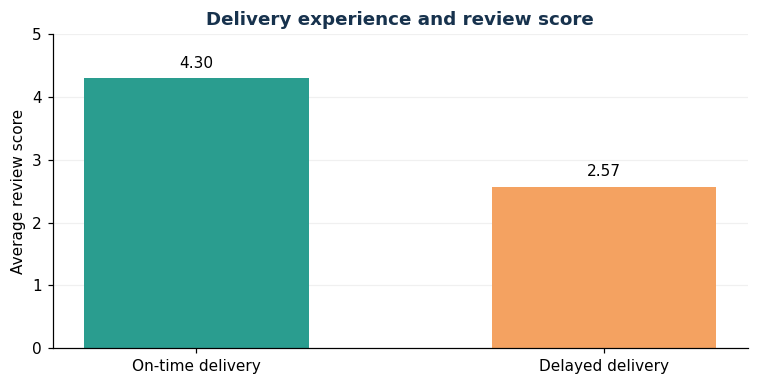

In [7]:
delivery = data["delivery"].set_index("metric")["value"]
on_time_score = float(delivery["on_time_avg_score"])
delayed_score = float(delivery["delayed_avg_score"])
display(pd.DataFrame([
    {"指标": "履约体验订单样本", "实际值": f"{int(float(delivery['sample_orders'])):,}"},
    {"指标": "配送延迟率", "实际值": f"{float(delivery['delay_rate_pct']):.2f}%"},
    {"指标": "准时订单平均评分", "实际值": f"{on_time_score:.2f}"},
    {"指标": "延迟订单平均评分", "实际值": f"{delayed_score:.2f}"},
    {"指标": "延迟订单评分相对下降（原始精度汇总）", "实际值": f"{float(delivery['score_drop_pct']):.2f}%"},
]))
fig, ax = plt.subplots(figsize=(7, 3.6))
bars = ax.bar(["On-time delivery", "Delayed delivery"], [on_time_score, delayed_score], color=[TEAL, ORANGE], width=0.55)
ax.bar_label(bars, fmt="%.2f", padding=5)
ax.set(title="Delivery experience and review score", ylabel="Average review score", ylim=(0, 5))
ax.grid(axis="y", alpha=0.18)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()
plt.close(fig)


## 7. 从发现到运营建议

运营规则生成的是目标人群与建议动作，不是已发送的任务或已验证的增长效果。下表只读取按规则聚合的人数，不展示客户名单。后续应通过随机实验评估增量效果，而不是把模型关联当作优惠策略的收益预测。

[A/B 测试设计（未实施）](../docs/ab_test_design.md)


In [8]:
display(data["campaigns"][["reason_code", "campaign_priority", "customer_count"]])
display(Markdown(
    f"- **首购培育：**历史一次性购买率 {overview['one_time_rate']:.2f}%，"
    f"加权 M1 留存率 {weighted_m1_pct:.2f}%，90 天跨日二购率 {repeat_pct:.4f}%；"
    "可围绕首购后窗口设计二购提醒与品类推荐实验。\n"
    f"- **分层召回：**完整高价值流失人群 {full_churned:,} 人，"
    "结合价值与履约受损优先级安排召回及服务补救。\n"
    f"- **满意度修复：**准时/延迟平均评分 {on_time_score:.2f}/{delayed_score:.2f}；"
    f"延迟与二购的调整后 p={drivers.loc['is_delayed', 'p_value']:.4f}，"
    "不能据此声称改善配送已带来二购提升。"
))


,reason_code,campaign_priority,customer_count
0,SECOND_PURCHASE,high,33527
1,CATEGORY_PROMO,medium,22600
2,WINBACK_HIGH_VALUE,high,10326
3,SERVICE_RECOVERY,high,4024
4,VIP_ENGAGE,medium_high,612
5,RETAIN_AT_RISK,high,335


- **首购培育：**历史一次性购买率 97.00%，加权 M1 留存率 0.48%，90 天跨日二购率 1.2969%；可围绕首购后窗口设计二购提醒与品类推荐实验。
- **分层召回：**完整高价值流失人群 10,915 人，结合价值与履约受损优先级安排召回及服务补救。
- **满意度修复：**准时/延迟平均评分 4.30/2.57；延迟与二购的调整后 p=0.5242，不能据此声称改善配送已带来二购提升。

## 8. 可复现性检查与限制

最后核对：客户分层人数、二购分组人数、加权 M1 与既有 SQL × Python 校验结果一致；所有源文件哈希与读取前相同。这里展示的是**已生成的数据库交叉验证记录**，不表示本 Notebook 重新连接数据库验证。

历史公开数据不能代表 Olist 当前经营状况；观察窗之后的购买行为不可见；缺少真实触达、成本和浏览曝光数据，不能报告利润、真实 CLV、因果增量或实验收益。需要更新底层分析时，请运行项目生产流程后再重跑本 Notebook。


In [9]:
assert data["validation"]["status"].eq("PASS").all()
for key, relative_path in SOURCES.items():
    assert sha256((ROOT / relative_path).read_bytes()).hexdigest() == input_hashes[key], relative_path
display(data["validation"][["metric", "sql_value", "python_value", "status"]])
print(
    f"检查通过：{len(SOURCES)} 份公开汇总输入未被改写；"
    f"已有交叉验证记录 {len(data['validation'])} 项全部 PASS；"
    f"加权 M1 留存率 {weighted_m1_pct:.2f}%。"
)


,metric,sql_value,python_value,status
0,total_customers,96096.00,96096.00,PASS
1,valid_orders,96478.00,96478.00,PASS
2,one_time_buyer_pct,97.00,97.00,PASS
3,repeat_rate_pct,3.00,3.00,PASS
4,total_payment,15422461.77,15422461.77,PASS
5,average_order_value,159.86,159.86,PASS
6,delay_rate_pct,7.98,7.98,PASS
7,on_time_avg_score,4.30,4.30,PASS
8,delayed_avg_score,2.57,2.57,PASS
9,high_value_churned,10915.00,10915.00,PASS


检查通过：9 份公开汇总输入未被改写；已有交叉验证记录 11 项全部 PASS；加权 M1 留存率 0.48%。
